In [18]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import diffrax
from diffrax import ControlTerm, MultiTerm, ODETerm
import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss, grad_loss
jax.config.update("jax_enable_x64", True)

### Generate samples from a Gaussian mixture

In [33]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1, 1.0],   # mean of first Gaussian
    [-.1, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

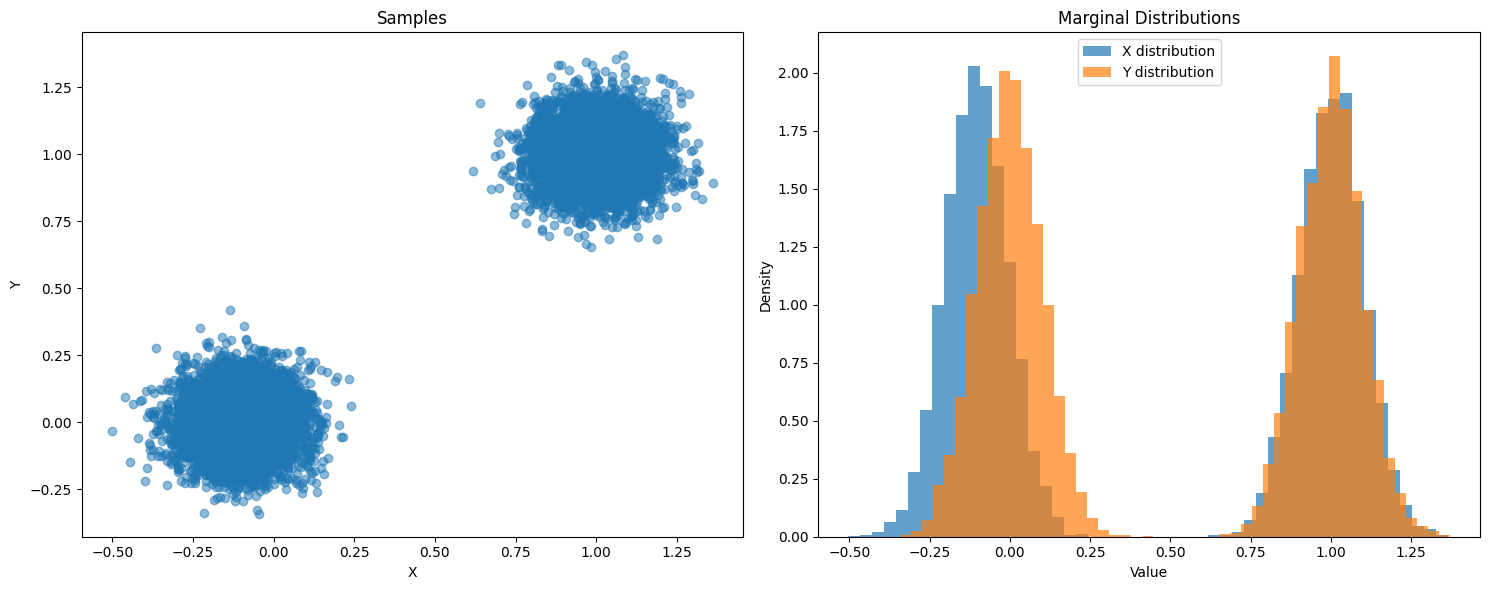

In [34]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Scatter plot of samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [35]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [36]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])



args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [37]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot energy landscape

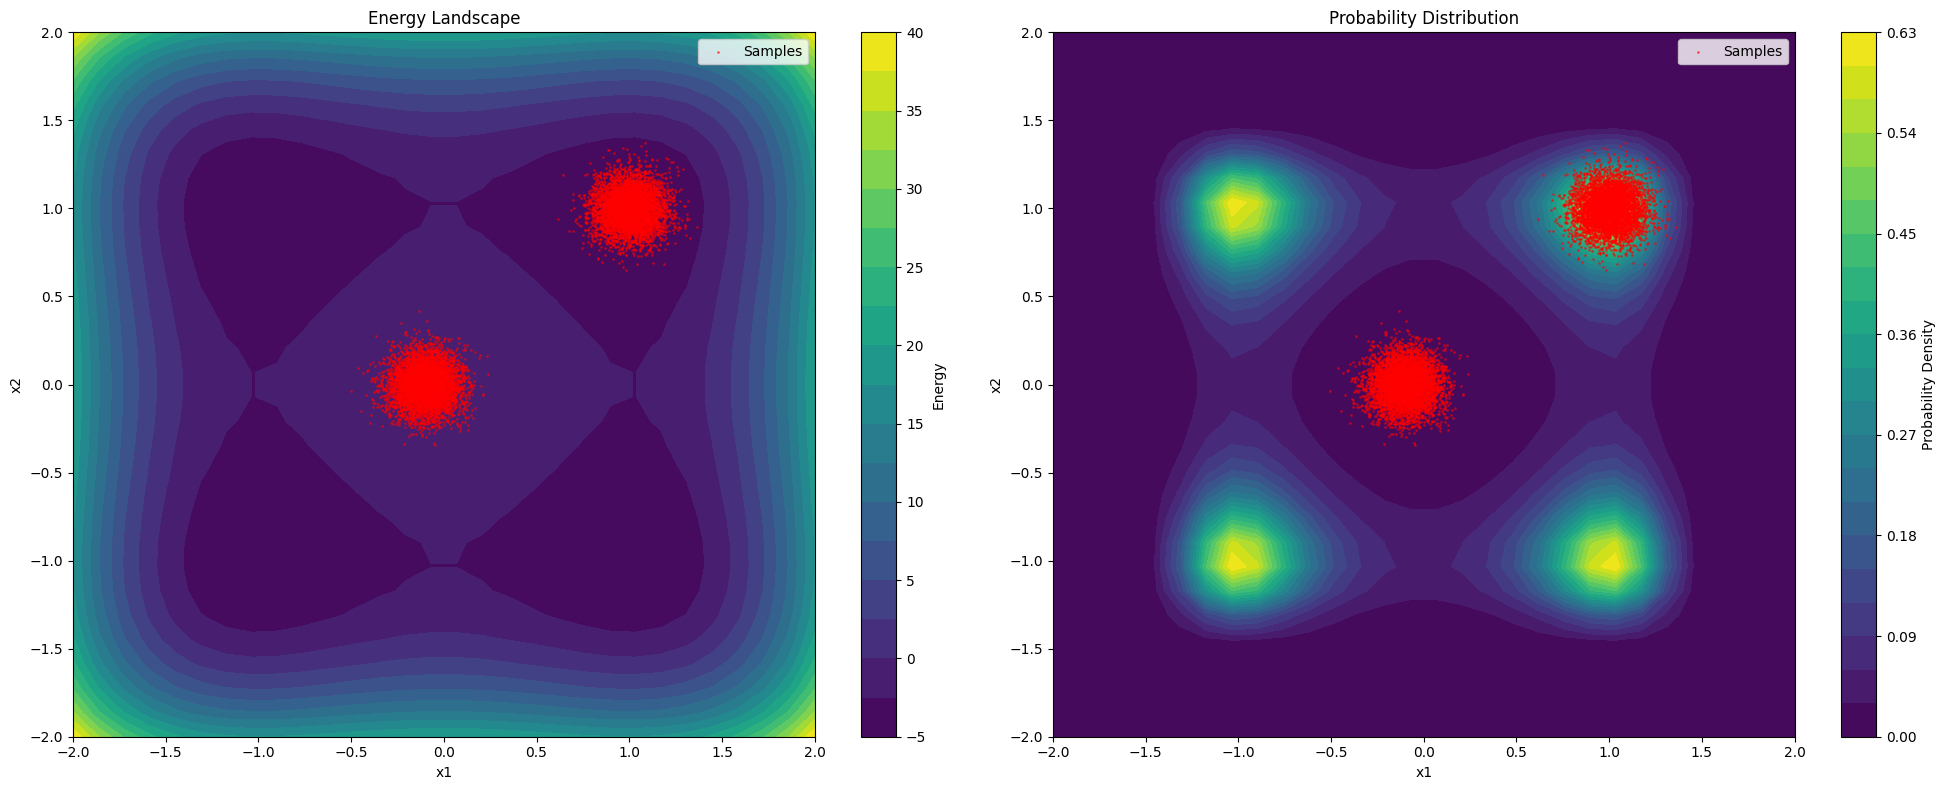

Total probability (should be ≈ 1): 1.000000
Maximum probability density: 0.629220
Minimum probability density: 0.000000


In [38]:
# Create a grid of phase values
n_points = 30
x1 = jnp.linspace(-2, 2, n_points)
x2 = jnp.linspace(-2, 2, n_points)
X1, X2 = jnp.meshgrid(x1, x2)

# Compute energy for each point in the grid
energy = jnp.zeros((n_points, n_points))
for i in range(n_points):
    for j in range(n_points):
        x = jnp.array([X1[i,j], X2[i,j]])
        energy = energy.at[i,j].set(energy_fn(x, flattened_args_initial))

# Compute probability distribution
prob = jnp.exp(-energy)
# Normalize probability (integrate to 1)
prob = prob / (jnp.sum(prob) * (x1[1]-x1[0]) * (x2[1]-x2[0]))

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot energy landscape
contour1 = ax1.contourf(X1, X2, energy, levels=20, cmap='viridis')
plt.colorbar(contour1, ax=ax1, label='Energy')
ax1.scatter(samples[:, 0], samples[:, 1], c='red', s=1, alpha=0.5, label='Samples')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Energy Landscape')
ax1.legend()

# Plot probability distribution
contour2 = ax2.contourf(X1, X2, prob, levels=20, cmap='viridis')
plt.colorbar(contour2, ax=ax2, label='Probability Density')
ax2.scatter(samples[:, 0], samples[:, 1], c='red', s=1, alpha=0.5, label='Samples')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Probability Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Total probability (should be ≈ 1): {jnp.sum(prob) * (x1[1]-x1[0]) * (x2[1]-x2[0]):.6f}")
print(f"Maximum probability density: {jnp.max(prob):.6f}")
print(f"Minimum probability density: {jnp.min(prob):.6f}")

In [39]:
# Define optimization parameters
learning_rate = 0.01
n_epochs = 20000
batch_size = 128

# Initialize optimizer
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(flattened_args_initial)

# Get score matching gradient results (only need to compute once)
score_matching_loss = setup_score_matching_loss(energy_fn, samples)
score_matching_grad = grad_loss(score_matching_loss, flattened_args_initial)


@partial(jax.jit, static_argnums=(3,))
def training_step(params, opt_state, samples, batch_size, key):
    """Single training step using batched samples"""
    # Get random batch of samples
    key, subkey = jr.split(key)
    n_samples = len(samples)
    idx = jr.randint(subkey, (batch_size,), 0, n_samples)
    batch = samples[idx]
    
    # Setup loss for this batch
    batch_score_matching_loss = setup_score_matching_loss(energy_fn, batch)
    
    # Get gradient of parameters for this batch
    dparams_sm = grad_loss(batch_score_matching_loss, params)    
    
    # Compute loss for this batch
    loss = batch_score_matching_loss(params)
    
    # Apply updates
    updates, opt_state = optimizer.update(dparams_sm, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, key, loss

# Training loop
key = jr.PRNGKey(0)
params_history = []
loss_history = []

params = flattened_args_initial

for epoch in range(n_epochs):
    key, subkey = jr.split(key)
    params, opt_state, key, loss = training_step(
        params, opt_state, samples, batch_size, subkey)
    
    # Store parameters and loss
    params_history.append(params)
    loss_history.append(loss)
    
    if epoch % 10 == 0:
        k_lin, k_duffing, c_lin, c_optomech = unflatten(params)
        print(f"Epoch {epoch}")
        print(f"k_lin:\n{k_lin}")
        print(f"k_duffing:\n{k_duffing}")
        print(f"c_lin:\n{c_lin}")
        print(f"c_optomech:\n{c_optomech}")
        print(f"Loss: {loss:.4f}")
        print("---")

Epoch 0
k_lin:
[-0.99 -0.99]
k_duffing:
[1.01 1.01]
c_lin:
[0.01]
c_optomech:
[0.01]
Loss: -8.8767
---
Epoch 10
k_lin:
[-0.91438278 -0.91048696]
k_duffing:
[1.09464199 1.09663798]
c_lin:
[0.1097582]
c_optomech:
[-0.04064689]
Loss: -14.5759
---
Epoch 20
k_lin:
[-0.85187575 -0.86631203]
k_duffing:
[1.16916094 1.16398736]
c_lin:
[0.20801312]
c_optomech:
[-0.1340524]
Loss: -14.4530
---
Epoch 30
k_lin:
[-0.76900536 -0.84514604]
k_duffing:
[1.25919861 1.21664454]
c_lin:
[0.30349158]
c_optomech:
[-0.22033296]
Loss: -26.3547
---
Epoch 40
k_lin:
[-0.6964465  -0.82896475]
k_duffing:
[1.34003983 1.26757358]
c_lin:
[0.3953054]
c_optomech:
[-0.30828441]
Loss: -31.3318
---
Epoch 50
k_lin:
[-0.6104557  -0.81281875]
k_duffing:
[1.42583654 1.31120151]
c_lin:
[0.48338355]
c_optomech:
[-0.38157933]
Loss: -33.4754
---
Epoch 60
k_lin:
[-0.53999782 -0.80373546]
k_duffing:
[1.50419252 1.34811694]
c_lin:
[0.56667956]
c_optomech:
[-0.45373235]
Loss: -39.0524
---
Epoch 70
k_lin:
[-0.48683096 -0.7842918 ]
k_duff

In [44]:
# Convert histories to arrays for plotting
slicing = 1
params_history = jnp.array(params_history[::slicing])
k_lin_history = jnp.zeros((len(params_history), N_osc))
k_duff_history = jnp.zeros((len(params_history), N_osc))
c_lin_history = jnp.zeros((len(params_history), 1))
c_optomech_history = jnp.zeros((len(params_history), 1))

for i in range(len(params_history)):
    k_lin, k_duff, c_lin, c_optomech = unflatten(params_history[i])
    k_lin_history = k_lin_history.at[i].set(k_lin)
    k_duff_history = k_duff_history.at[i].set(k_duff)
    c_lin_history = c_lin_history.at[i].set(c_lin)
    c_optomech_history = c_optomech_history.at[i].set(c_optomech)

loss_history = jnp.array(loss_history[::slicing])

# Find index of lowest loss
best_idx = jnp.argmin(loss_history)

# Get parameters corresponding to lowest loss
k_lin_final = k_lin_history[best_idx]
k_duff_final = k_duff_history[best_idx]
c_lin_final = c_lin_history[best_idx]
c_optomech_final = c_optomech_history[best_idx]

# Create tuple of best args in same structure as initial args
args_final = (k_lin_final, k_duff_final, c_lin_final, c_optomech_final)

# Flatten using the same unflatten function from earlier
flattened_args_final, _ = flatten_util.ravel_pytree(args_final)

print(f"Best loss: {loss_history[best_idx]:.4e}")
print(f"Found at epoch: {best_idx * slicing}")

Best loss: -7.3526e+01
Found at epoch: 472


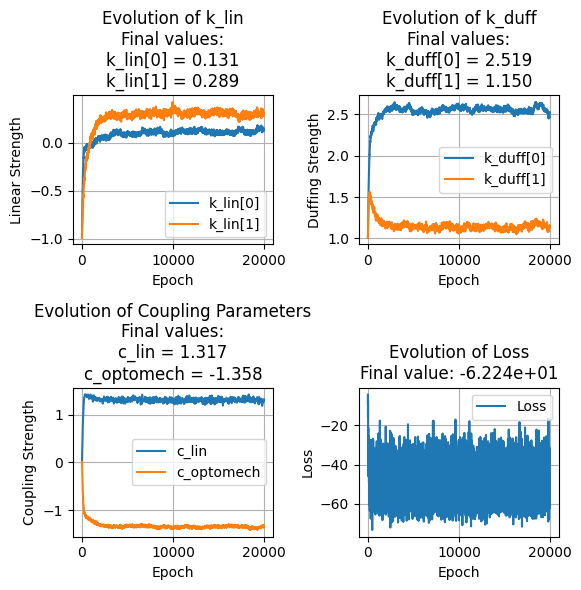

In [41]:
# Create figure with 4 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# Plot k_lin evolution
for i in range(N_osc):
    axes[0, 0].plot(k_lin_history[:, i], label=f'k_lin[{i}]')
axes[0, 0].set_title(f'Evolution of k_lin\nFinal values:\n' + 
                     '\n'.join([f'k_lin[{i}] = {k_lin_history[-1,i]:.3f}' 
                               for i in range(N_osc)]))
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Linear Strength')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot k_duff evolution
for i in range(N_osc):
    axes[0, 1].plot(k_duff_history[:, i], label=f'k_duff[{i}]')
axes[0, 1].set_title(f'Evolution of k_duff\nFinal values:\n' + 
                     '\n'.join([f'k_duff[{i}] = {k_duff_history[-1,i]:.3f}' 
                               for i in range(N_osc)]))
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Duffing Strength')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot c_lin and c_optomech evolution
axes[1, 0].plot(c_lin_history, label='c_lin')
axes[1, 0].plot(c_optomech_history, label='c_optomech')
axes[1, 0].set_title(f'Evolution of Coupling Parameters\nFinal values:\n' +
                     f'c_lin = {c_lin_history[-1,0]:.3f}\n' +
                     f'c_optomech = {c_optomech_history[-1,0]:.3f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Coupling Strength')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot loss evolution
axes[1, 1].plot(loss_history, label='Loss')
axes[1, 1].set_title(f'Evolution of Loss\nFinal value: {loss_history[-1]:.3e}')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)



plt.tight_layout()
plt.show()

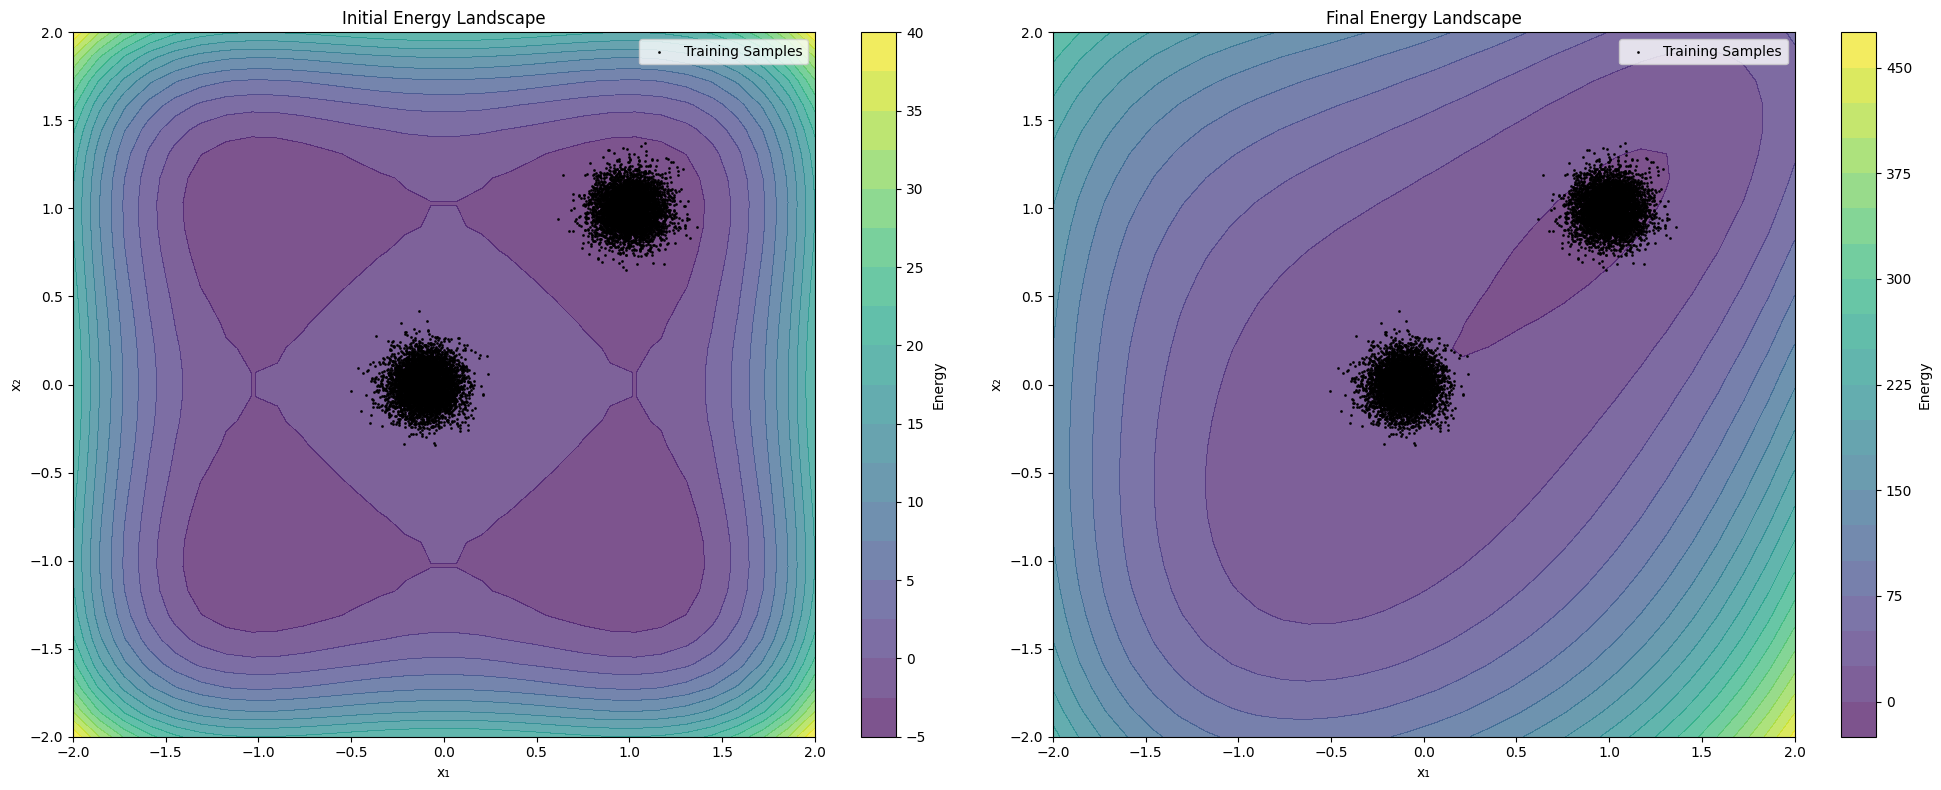

In [46]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot initial energy landscape
energy_initial = jnp.zeros((n_points, n_points))
energy_final = jnp.zeros((n_points, n_points))
for i in range(n_points):
    for j in range(n_points):
        x = jnp.array([X1[i,j], X2[i,j]])
        energy_initial = energy_initial.at[i,j].set(energy_fn(x, flattened_args_initial))
        energy_final = energy_final.at[i,j].set(energy_fn(x, flattened_args_final))

contour1 = ax1.contourf(X1, X2, energy_initial, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour1, ax=ax1, label='Energy')
ax1.scatter(samples[:, 0], samples[:, 1], c='black', s=1, alpha=0.9, label='Training Samples')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Initial Energy Landscape')
ax1.legend()


contour2 = ax2.contourf(X1, X2, energy_final, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour2, ax=ax2, label='Energy')
ax2.scatter(samples[:, 0], samples[:, 1], c='black', s=1, alpha=0.9, label='Training Samples')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Final Energy Landscape')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Compare gradient differences with score_matching_loss for different dt values
dt_values = jnp.logspace(-18, 1, 30)  # logarithmically spaced dt values
key = jr.PRNGKey(1)

# Get score matching gradient results (only need to compute once)
score_matching_loss = setup_score_matching_loss(energy_fn, samples)
score_matching_grad = grad_loss(score_matching_loss, flattened_args_final)

# Initialize arrays to store results
n_params = len(flattened_args_final)
relative_differences = jnp.zeros((len(dt_values), n_params))
total_relative_differences = jnp.zeros(len(dt_values))  # New array for total differences

# Loop over dt values
for i, dt in enumerate(dt_values):
    key, subkey = jr.split(key)
    
    # Get CD1 gradient for this dt
    cd1_grad = -CD1_gradient(energy_fn, samples, flattened_args_final, 
                            dt=dt, D=1, key=subkey, num_noise_samples=0)
    
    # Calculate relative difference for each parameter
    rel_diff = jnp.abs(cd1_grad - score_matching_grad) / jnp.abs(score_matching_grad)
    relative_differences = relative_differences.at[i].set(rel_diff)
    
    # Calculate total relative difference using L2 norm
    total_rel_diff = jnp.linalg.norm(cd1_grad - score_matching_grad) / jnp.linalg.norm(score_matching_grad)
    total_relative_differences = total_relative_differences.at[i].set(total_rel_diff)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# First subplot: Individual parameter differences
param_names = ['k_lin_1', 'k_lin_2', 'k_duff_1', 'k_duff_2', 'c_lin', 'c_optomech']
for param_idx in range(n_params):
    ax1.loglog(dt_values, relative_differences[:, param_idx], 'o-', 
               label=param_names[param_idx])

ax1.set_xlabel('dt')
ax1.set_ylabel('Relative Difference')
ax1.set_title('Individual Parameter Relative Differences')
ax1.grid(True)
ax1.legend()

# Second subplot: Total gradient difference
ax2.loglog(dt_values, total_relative_differences, 'o-', color='black', label='Total gradient')
ax2.set_xlabel('dt')
ax2.set_ylabel('Total Relative Difference')
ax2.set_title('Total Gradient Relative Difference (L2 norm)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print the minimum relative differences
print("\nIndividual parameter minimum differences:")
for param_idx in range(n_params):
    min_idx = jnp.argmin(relative_differences[:, param_idx])
    print(f"\n{param_names[param_idx]}:")
    print(f"Minimum relative difference: {relative_differences[min_idx, param_idx]:.2e}")
    print(f"Optimal dt: {dt_values[min_idx]:.2e}")

print("\nTotal gradient minimum difference:")
min_total_idx = jnp.argmin(total_relative_differences)
print(f"Minimum total relative difference: {total_relative_differences[min_total_idx]:.2e}")
print(f"Optimal dt: {dt_values[min_total_idx]:.2e}")

In [14]:
# def drift_x_fn(t, state, args):
#     """
#     Drift function for the XY model with effective temperature
#     Args:
#         t: time
#         state: array of phases (shape: N_osc)
#         args: tuple containing (W, h)
#     Returns:
#         Array of phase velocities
#     """
#     W, h = args
#     # Compute force from energy gradient
#     dE_dtheta = jax.grad(XY_energy, argnums=0)(state, W, h)
    
#     # Damping term
#     gamma = 1.0  # Damping coefficient, adjust as needed
    
#     dtheta_dt = -gamma * dE_dtheta
    
#     return dtheta_dt

# def diffusion_x_fn(t, state, args):
#     """
#     Diffusion function for the XY model with effective temperature
#     Args:
#         t: time
#         state: array of phases (shape: N_osc)
#         args: additional arguments
#     Returns:
#         Noise matrix (shape: N_osc x 1)
#     """
#     T_eff = 1.0  # Effective temperature, adjust as needed
#     gamma = 1.0  # Same damping coefficient as in drift
    
#     noise_strength = jnp.sqrt(2 * gamma * T_eff)
#     noise_matrix = jnp.eye(N_osc)
#     return noise_strength * noise_matrix



In [15]:
# # Calculate characteristic time scales
# gamma = 1.0
# T_eff = 1.0
# J = jnp.max(jnp.abs(W))  # Coupling strength

# tau_relax = 1/gamma
# tau_diffusion = gamma/(2*T_eff)

# print(f"Relaxation time scale: {tau_relax:.2f}")
# print(f"Diffusion time scale: {tau_diffusion:.2f}")

# # Set simulation time accordingly
# t0 = 0.0
# t1 = 100 * max(tau_relax, tau_diffusion)  # Simulate for 10x the longest time scale
# dt0 = min(tau_relax, tau_diffusion) / 10  # Initial time step should be smaller than fastest time scale

# print(f"\nSuggested simulation parameters:")
# print(f"Total time: {t1:.2f}")
# print(f"Initial dt: {dt0:.2f}")

# ts = jnp.linspace(t0, t1, 10000)
# dt = ts[1] - ts[0]

# y0_x = jnp.array([jnp.pi,jnp.pi])

In [16]:
# # Update shape to match number of oscillators
# w_shape = (N_osc,)  # state is just phases for each oscillator
# brownian_motion = diffrax.VirtualBrownianTree(
#     t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
# )
# terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# saveat = diffrax.SaveAt(ts=ts)


# # sample 1000 points
# solution_x = diffrax.diffeqsolve(
#     terms_x,
#     solver=diffrax.SRA1(),
#     t0=t0,
#     t1=t1,
#     dt0=dt0,
#     y0=y0_x,
#     args=(),
#     saveat=saveat,
#     progress_meter=diffrax.TqdmProgressMeter(),
#     max_steps=1000000000,
#     stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
# )
# sde_samples_x = solution_x.ys

In [17]:
# # Calculate number of timesteps corresponding to one relaxation time
# relax_steps = int(1/(gamma * dt))

# # Thin the samples by taking every relax_steps point
# sde_samples_x = solution_x.ys[::relax_steps]
# ts = ts[::relax_steps]

In [18]:
# # Create figure with a grid of subplots
# fig = plt.figure(figsize=(16, 12))
# gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# # Top left: Phase trajectories
# ax1 = fig.add_subplot(gs[0, 0])
# # Mod 2π for time trajectories
# ax1.plot(ts, jnp.mod(sde_samples_x[:, 0], 2*jnp.pi), label='θ₁(t)')
# ax1.plot(ts, jnp.mod(sde_samples_x[:, 1], 2*jnp.pi), label='θ₂(t)')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Phase (rad)')
# ax1.set_title('SDE Simulation: Phase vs Time')
# ax1.grid(True)
# ax1.legend()

# # Top right: Phase space with Energy contour
# ax2 = fig.add_subplot(gs[0, 1])
# contour = ax2.contourf(X1, X2, energy, levels=20, cmap='RdYlBu')
# plt.colorbar(contour, ax=ax2, label='Energy')

# # Mod 2π for phase space trajectory
# wrapped_x = jnp.mod(sde_samples_x, 2*jnp.pi)
# ax2.scatter(wrapped_x[:, 0], wrapped_x[:, 1], c='g', s=1, alpha=0.9999, label='Trajectory')
# ax2.plot(wrapped_x[0, 0], wrapped_x[0, 1], 'go', label='Start', markersize=10)


# ax2.set_xlabel('θ₁')
# ax2.set_ylabel('θ₂')
# ax2.set_title('Phase Space (Torus)')
# ax2.legend()

# # Bottom left: θ₁ histogram (mod 2π)
# ax3 = fig.add_subplot(gs[1, 0])
# ax3.hist(wrapped_x[:, 0], bins=50, density=True, alpha=0.7, label='θ₁ distribution')
# ax3.set_xlabel('θ₁')
# ax3.set_ylabel('Probability Density')
# ax3.grid(True)
# ax3.legend()

# # Bottom right: θ₂ histogram (mod 2π)
# ax4 = fig.add_subplot(gs[1, 1])
# ax4.hist(wrapped_x[:, 1], bins=50, density=True, alpha=0.7, label='θ₂ distribution')
# ax4.set_xlabel('θ₂')
# ax4.set_ylabel('Probability Density')
# ax4.grid(True)
# ax4.legend()

# plt.tight_layout()
# # Add title with parameters
# title = f'T_eff={T_eff}, γ={gamma}'
# plt.suptitle(title, y=1.02)

# plt.show()